## Import required libraries

In [1]:
import numpy as np
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt

## Images load and into array (Preprocessing)

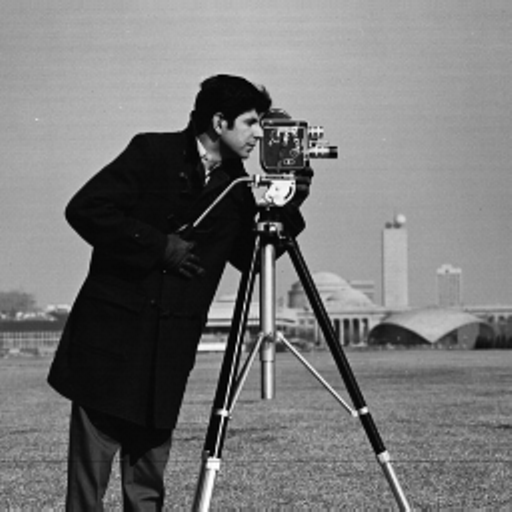

In [2]:
image = Image.open("./assets/cameraman.png").convert("L")
display(image)

In [3]:
image_array = np.array(image)
height, width = image_array.shape

# why reshape ?  here it doesn't matter ? 
data = image_array.reshape(height, width)

## standardize data 
- **centring** ensures PCA focuses on variance, not absolute values

In [4]:
mean = np.mean(data, axis=0)
centered_data = data - mean

## covariance matrix
- **capturing relationship**  to find importance ? 

In [5]:
# row var ?  treat columns as variable instead of row
cov_matrix = np.cov(centered_data, rowvar=False)

## eigenvalues and eigenvectors

In [6]:
eigenvalues, eigenvector = np.linalg.eigh(cov_matrix)

# sorting in desc. order

# eigen vector = principal components 
# but only after sorting. And only the ones you pick.

# how is argsort different than sort ? it returns indices that would sort arr
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices] 
eigenvector = eigenvector[:, sorted_indices] # principal components ? 

## picking principal component (important ones)

- but how many to pick ? - `explained-variance`
- how much info to which components

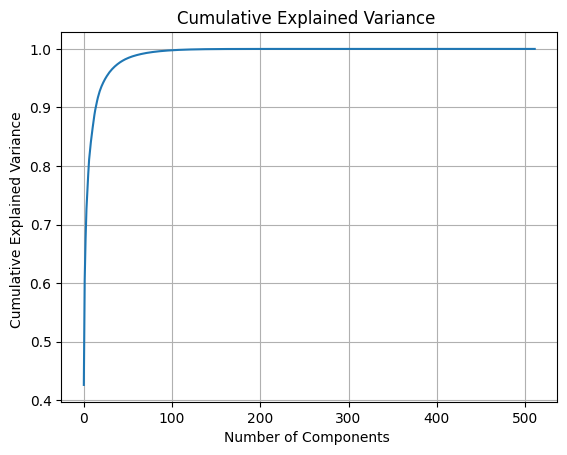

In [7]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
plt.plot(np.cumsum(explained_variance_ratio))
plt.title("Cumulative Explained Variance ")
plt.xlabel("Number of Components ")
plt.ylabel("Cumulative Explained Variance ")
plt.grid(True)
plt.show()

## picking top k principal component

- larger k, more info ? 

In [8]:
k = 50
components = eigenvector[:, :k]

## finally compress the image

In [9]:
# project data on to components 
compressed_data = np.dot(centered_data, components)

# the dimensions are changed
compressed_data.shape

(512, 50)

## reconstructing image

In [10]:
# how ?  
decompressed_data = np.dot(compressed_data, components.T)

## Visualizing data

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

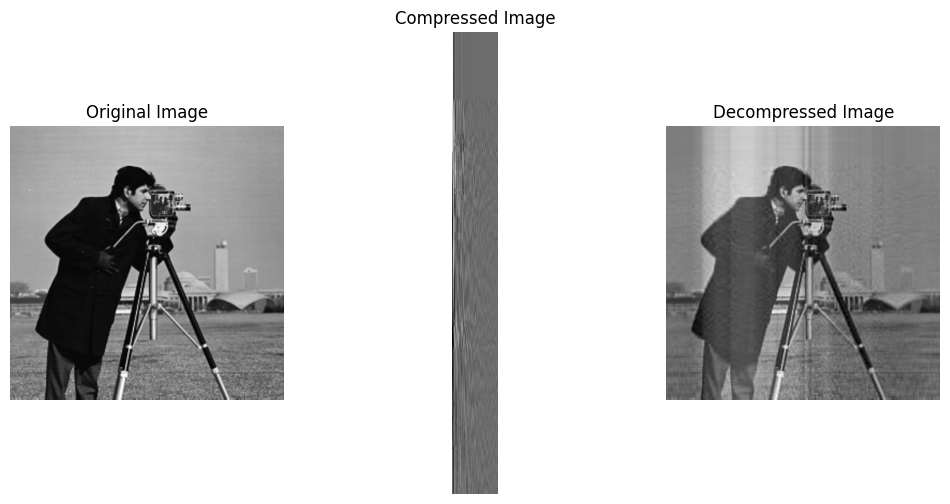

In [11]:
plt.figure(figsize=(12, 6))

# original
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# compressed 
plt.subplot(1, 3, 2)
plt.imshow(compressed_data, cmap="gray")
plt.title("Compressed Image")
plt.axis("off")

# decompressed 
plt.subplot(1, 3, 3)
plt.imshow(decompressed_data, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")